# Modelos Não Supervisionados

Usamos clustering para descobrir **agrupamentos naturais** de voos sem usar a variável alvo (`IS_DELAYED`). Após o clustering, analisamos se os clusters encontrados correlacionam com atrasos — validando se o modelo capturou padrões reais.

**Modelos:**
1. **K-Means** — agrupa voos em k clusters por proximidade no espaço de features
2. **DBSCAN** — identifica clusters por densidade, detectando automaticamente ruído (outliers)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Carregamento e Preparação dos Dados

In [2]:
df = pd.read_csv('../data/refined/flights_features.csv')

# Mesma amostra de 10% usada no modelo supervisionado
df = df.sample(frac=0.1, random_state=42)
print(f'Shape: {df.shape}')
df.head()

Shape: (571401, 16)


,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_TIME,DISTANCE,IS_DELAYED,SCHED_DEP_HOUR,SCHED_ARR_HOUR,ROUTE_DELAY_RATE,AIRLINE_ORIGIN_DELAY_RATE,HOUR_ORIGIN_DELAY_RATE,AIRLINE_ENC,ORIGIN_DELAY_RATE,DEST_DELAY_RATE,ORIGIN_STATE_ENC,DEST_STATE_ENC
3258731,7,27,1,75.0,318,0,16,16,0.219020,0.232010,0.226836,9,0.194688,0.183358,18,51
4767503,10,30,5,165.0,950,0,18,21,0.169184,0.053452,0.174507,3,0.119143,0.172459,54,54
4367149,10,5,1,115.0,672,0,11,13,0.143731,0.132343,0.115880,13,0.128693,0.140386,54,54
5040207,11,17,2,62.0,214,0,13,14,0.139520,0.136012,0.138563,3,0.164370,0.187517,10,10
3989679,9,11,5,60.0,224,0,6,7,0.157845,0.163721,0.082994,9,0.140254,0.164567,50,50


In [3]:
# Separar features e target
# IS_DELAYED NÃO é usada para treinar — só para validar os clusters depois
y_true = df['IS_DELAYED'].values
X = df.drop(columns=['IS_DELAYED'])

# Normalizar — obrigatório para K-Means e DBSCAN (baseados em distância)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features para clustering: {X.columns.tolist()}')
print(f'Shape X_scaled: {X_scaled.shape}')

Features para clustering: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_TIME', 'DISTANCE', 'SCHED_DEP_HOUR', 'SCHED_ARR_HOUR', 'ROUTE_DELAY_RATE', 'AIRLINE_ORIGIN_DELAY_RATE', 'HOUR_ORIGIN_DELAY_RATE', 'AIRLINE_ENC', 'ORIGIN_DELAY_RATE', 'DEST_DELAY_RATE', 'ORIGIN_STATE_ENC', 'DEST_STATE_ENC']
Shape X_scaled: (571401, 15)


## 3. Modelo 1 — K-Means

O K-Means divide os dados em **k grupos** minimizando a distância intra-cluster. Precisamos escolher o k ideal usando o **Método do Cotovelo** (inércia) e o **Silhouette Score**.

In [4]:
# Método do Cotovelo + Silhouette Score para k = 2 a 10
# Usamos uma sub-amostra para acelerar essa busca
X_search = X_scaled[:50000]

inercias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_search)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_search, labels, sample_size=10000, random_state=42))
    print(f'  k={k:2d}  inércia={km.inertia_:>12.0f}  silhouette={silhouettes[-1]:.4f}')

  k= 2  inércia=      639678  silhouette=0.1353
  k= 3  inércia=      578518  silhouette=0.1274
  k= 4  inércia=      529355  silhouette=0.1349
  k= 5  inércia=      502455  silhouette=0.1170
  k= 6  inércia=      482031  silhouette=0.1036
  k= 7  inércia=      470319  silhouette=0.0941
  k= 8  inércia=      459704  silhouette=0.0903
  k= 9  inércia=      450129  silhouette=0.0890
  k=10  inércia=      442604  silhouette=0.0863


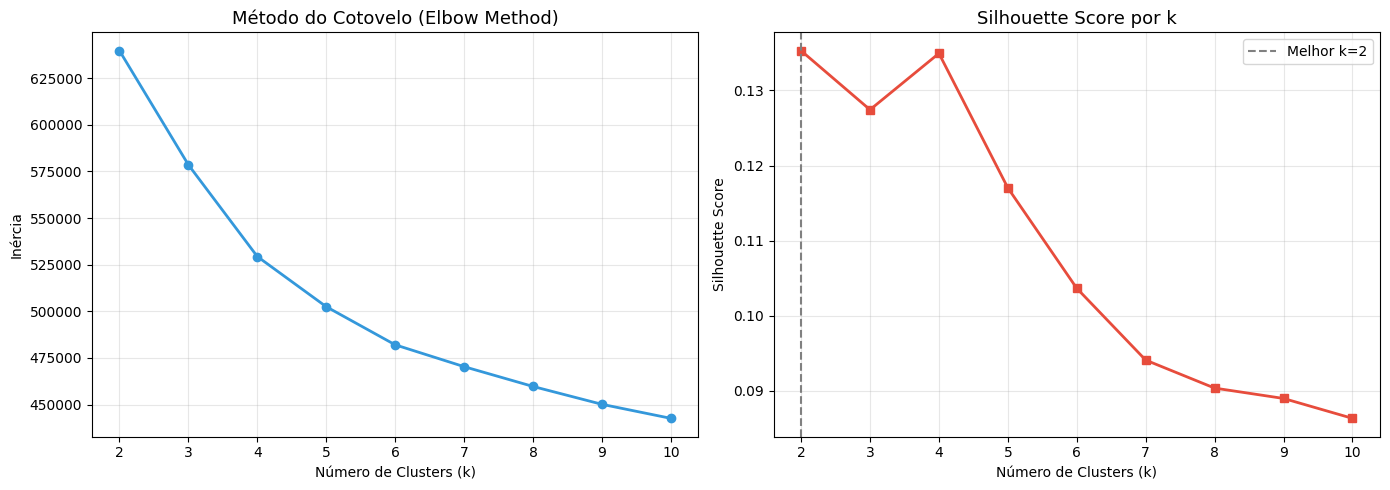


Melhor k pelo Silhouette Score: 2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cotovelo
axes[0].plot(list(k_range), inercias, marker='o', linewidth=2, color='#3498db')
axes[0].set_title('Método do Cotovelo (Elbow Method)', fontsize=13)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(k_range), silhouettes, marker='s', linewidth=2, color='#e74c3c')
best_k = list(k_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k, color='gray', linestyle='--', label=f'Melhor k={best_k}')
axes[1].set_title('Silhouette Score por k', fontsize=13)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'\nMelhor k pelo Silhouette Score: {best_k}')

In [6]:
# Treinar K-Means com o k escolhido no dataset completo (10%)
KMEANS_K = best_k

km_final = KMeans(n_clusters=KMEANS_K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

df_result = X.copy()
df_result['CLUSTER_KM'] = km_labels
df_result['IS_DELAYED'] = y_true

print(f'K-Means treinado com k={KMEANS_K}')
print(f'\nDistribuição dos clusters:')
for c, cnt in pd.Series(km_labels).value_counts().sort_index().items():
    print(f'  Cluster {c}: {cnt:>8,} voos ({cnt/len(km_labels)*100:.1f}%)')

K-Means treinado com k=2

Distribuição dos clusters:
  Cluster 0:  227,265 voos (39.8%)
  Cluster 1:  344,136 voos (60.2%)


In [7]:
# Perfil de cada cluster — médias das features
cluster_profile = df_result.groupby('CLUSTER_KM').mean().round(3)
print('Perfil médio por cluster:')
print(cluster_profile.T.to_string())

Perfil médio por cluster:
CLUSTER_KM                       0        1
MONTH                        7.261    6.081
DAY                         15.689   15.705
DAY_OF_WEEK                  3.946    3.936
SCHEDULED_TIME             131.323  149.028
DISTANCE                   749.018  875.267
SCHED_DEP_HOUR              11.021   14.336
SCHED_ARR_HOUR              12.714   15.913
ROUTE_DELAY_RATE             0.143    0.215
AIRLINE_ORIGIN_DELAY_RATE    0.146    0.213
HOUR_ORIGIN_DELAY_RATE       0.131    0.223
AIRLINE_ENC                  6.011    7.230
ORIGIN_DELAY_RATE            0.158    0.205
DEST_DELAY_RATE              0.167    0.199
ORIGIN_STATE_ENC            31.567   22.253
DEST_STATE_ENC              30.375   23.043
IS_DELAYED                   0.117    0.232


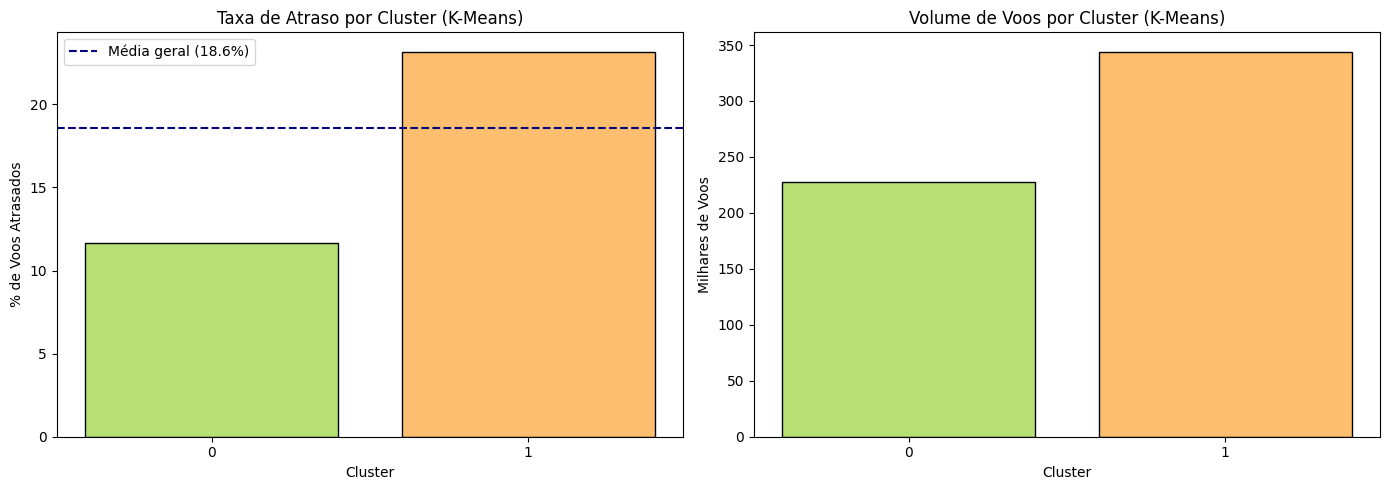

            Total de Voos  Taxa de Atraso (%)
CLUSTER_KM                                   
0                  227265               11.66
1                  344136               23.18


In [8]:
# Taxa de atraso por cluster — validação do clustering
delay_by_cluster = df_result.groupby('CLUSTER_KM')['IS_DELAYED'].agg(['mean', 'count'])
delay_by_cluster.columns = ['Taxa de Atraso', 'Total de Voos']
delay_by_cluster['Taxa de Atraso (%)'] = (delay_by_cluster['Taxa de Atraso'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de atraso por cluster
colors = sns.color_palette('RdYlGn_r', KMEANS_K)
axes[0].bar(delay_by_cluster.index.astype(str), delay_by_cluster['Taxa de Atraso (%)'],
            color=colors, edgecolor='black')
axes[0].axhline(y=y_true.mean()*100, color='navy', linestyle='--', label=f'Média geral ({y_true.mean()*100:.1f}%)')
axes[0].set_title('Taxa de Atraso por Cluster (K-Means)', fontsize=12)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% de Voos Atrasados')
axes[0].legend()

# Volume por cluster
axes[1].bar(delay_by_cluster.index.astype(str), delay_by_cluster['Total de Voos'] / 1000,
            color=colors, edgecolor='black')
axes[1].set_title('Volume de Voos por Cluster (K-Means)', fontsize=12)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Milhares de Voos')

plt.tight_layout()
plt.show()

print(delay_by_cluster[['Total de Voos', 'Taxa de Atraso (%)']].to_string())

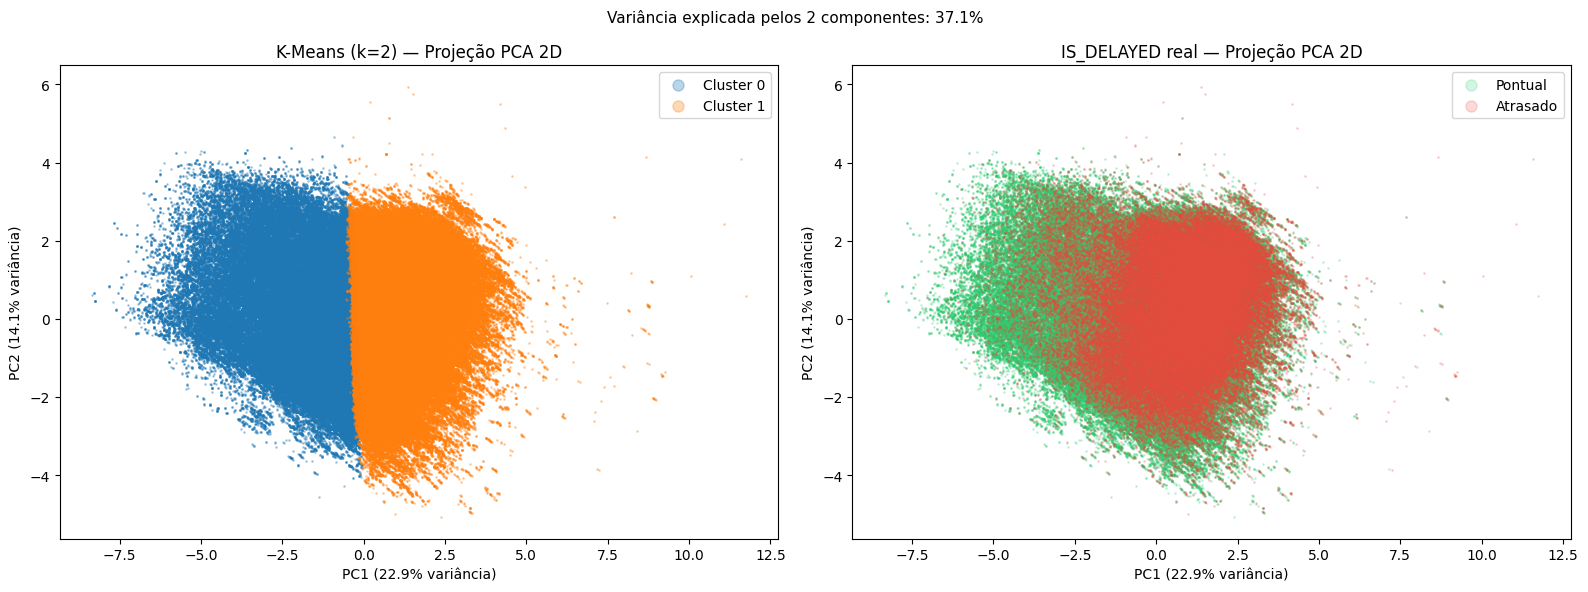

In [9]:
# Visualização 2D com PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colorido por cluster K-Means
for c in range(KMEANS_K):
    mask = km_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.3, label=f'Cluster {c}')
axes[0].set_title(f'K-Means (k={KMEANS_K}) — Projeção PCA 2D', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
axes[0].legend(markerscale=8)

# Colorido pela variável alvo real
for label, name, color in [(0, 'Pontual', '#2ecc71'), (1, 'Atrasado', '#e74c3c')]:
    mask = y_true == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.2, label=name, color=color)
axes[1].set_title('IS_DELAYED real — Projeção PCA 2D', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
axes[1].legend(markerscale=8)

plt.suptitle(f'Variância explicada pelos 2 componentes: {sum(pca.explained_variance_ratio_)*100:.1f}%', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Modelo 2 — DBSCAN

O DBSCAN (Density-Based Spatial Clustering of Applications with Noise) agrupa pontos por **densidade local**, sem precisar definir o número de clusters antecipadamente. Pontos em regiões esparsas são classificados como **ruído (-1)**.

Parâmetros principais:
- `eps` — raio da vizinhança de cada ponto
- `min_samples` — mínimo de pontos para formar um cluster

> Por ser mais lento que o K-Means, usamos uma sub-amostra de **3%** do dataset.

Sub-amostra para DBSCAN: 17,142 voos


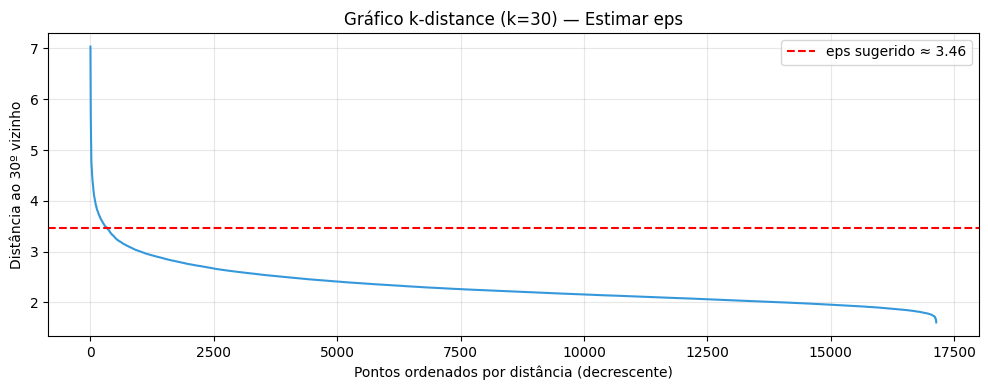

eps sugerido pelo gráfico: 3.46
min_samples usado: 30


In [10]:
# Sub-amostra para DBSCAN (3% do dataset)
DBSCAN_SAMPLE = int(len(X_scaled) * 0.03)
np.random.seed(42)
idx = np.random.choice(len(X_scaled), DBSCAN_SAMPLE, replace=False)
X_db = X_scaled[idx]
y_db = y_true[idx]

print(f'Sub-amostra para DBSCAN: {len(X_db):,} voos')

# Gráfico k-distance para estimar eps ideal
# Para cada ponto, calculamos a distância ao k-ésimo vizinho (k = min_samples)
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 2 * X.shape[1]  # regra: 2 * número de features
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_db)
distances, _ = nn.kneighbors(X_db)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, linewidth=1.5, color='#3498db')
plt.title(f'Gráfico k-distance (k={MIN_SAMPLES}) — Estimar eps', fontsize=12)
plt.xlabel('Pontos ordenados por distância (decrescente)')
plt.ylabel(f'Distância ao {MIN_SAMPLES}º vizinho')
plt.grid(True, alpha=0.3)

# Marcar o ponto de inflexão sugerido
inflex_idx = int(len(k_distances) * 0.02)
eps_sugerido = round(k_distances[inflex_idx], 2)
plt.axhline(y=eps_sugerido, color='red', linestyle='--', label=f'eps sugerido ≈ {eps_sugerido}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'eps sugerido pelo gráfico: {eps_sugerido}')
print(f'min_samples usado: {MIN_SAMPLES}')

In [11]:
# Treinar DBSCAN
db = DBSCAN(eps=eps_sugerido, min_samples=MIN_SAMPLES, n_jobs=-1)
db_labels = db.fit_predict(X_db)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'Clusters encontrados:  {n_clusters}')
print(f'Pontos de ruído:       {n_noise:,}  ({n_noise/len(db_labels)*100:.1f}%)')
print(f'\nDistribuição dos clusters:')
for c, cnt in pd.Series(db_labels).value_counts().sort_index().items():
    label = 'Ruído' if c == -1 else f'Cluster {c}'
    print(f'  {label}: {cnt:>8,} voos ({cnt/len(db_labels)*100:.1f}%)')

Clusters encontrados:  1
Pontos de ruído:       73  (0.4%)

Distribuição dos clusters:
  Ruído:       73 voos (0.4%)
  Cluster 0:   17,069 voos (99.6%)


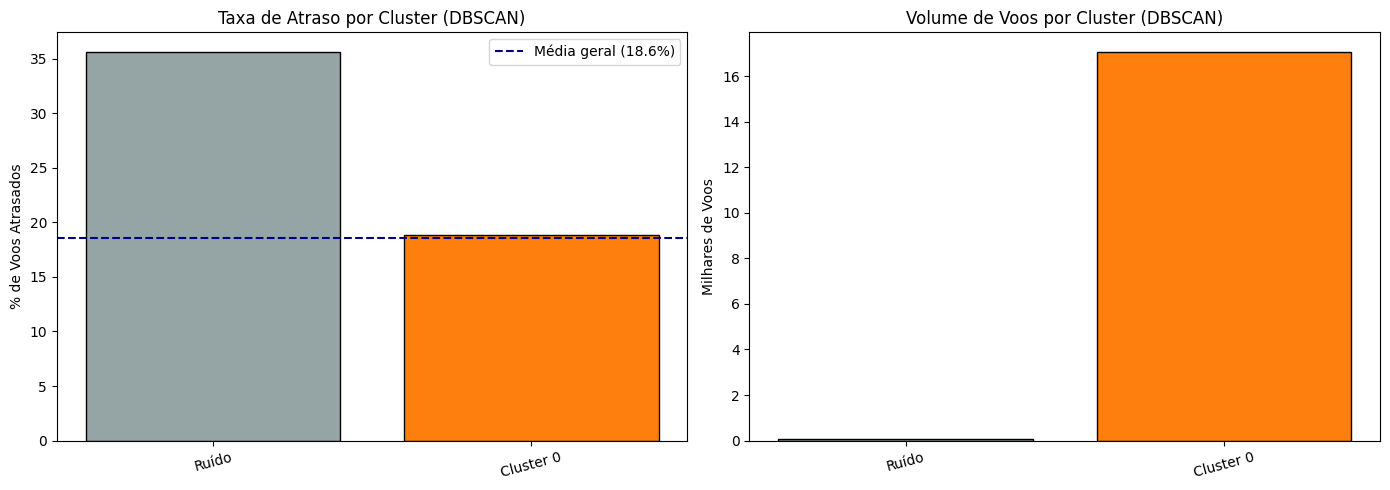

            Total  Taxa (%)
CLUSTER_DB                 
Ruído          73     35.62
Cluster 0   17069     18.88


In [12]:
# Taxa de atraso por cluster DBSCAN
# X.iloc[idx] usa indexação posicional — correto para índices gerados por np.random.choice
df_db = X.iloc[idx].reset_index(drop=True)
df_db['CLUSTER_DB'] = db_labels
df_db['IS_DELAYED'] = y_db

delay_db = df_db.groupby('CLUSTER_DB')['IS_DELAYED'].agg(['mean', 'count'])
delay_db.columns = ['Taxa de Atraso', 'Total']
delay_db['Taxa (%)'] = (delay_db['Taxa de Atraso'] * 100).round(2)
delay_db.index = delay_db.index.map(lambda x: 'Ruído' if x == -1 else f'Cluster {x}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_db = ['#95a5a6' if 'Ruído' in str(i) else sns.color_palette('tab10')[j]
             for j, i in enumerate(delay_db.index)]

axes[0].bar(delay_db.index.astype(str), delay_db['Taxa (%)'], color=colors_db, edgecolor='black')
axes[0].axhline(y=y_true.mean()*100, color='navy', linestyle='--', label=f'Média geral ({y_true.mean()*100:.1f}%)')
axes[0].set_title('Taxa de Atraso por Cluster (DBSCAN)', fontsize=12)
axes[0].set_ylabel('% de Voos Atrasados')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

axes[1].bar(delay_db.index.astype(str), delay_db['Total'] / 1000, color=colors_db, edgecolor='black')
axes[1].set_title('Volume de Voos por Cluster (DBSCAN)', fontsize=12)
axes[1].set_ylabel('Milhares de Voos')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(delay_db[['Total', 'Taxa (%)']].to_string())

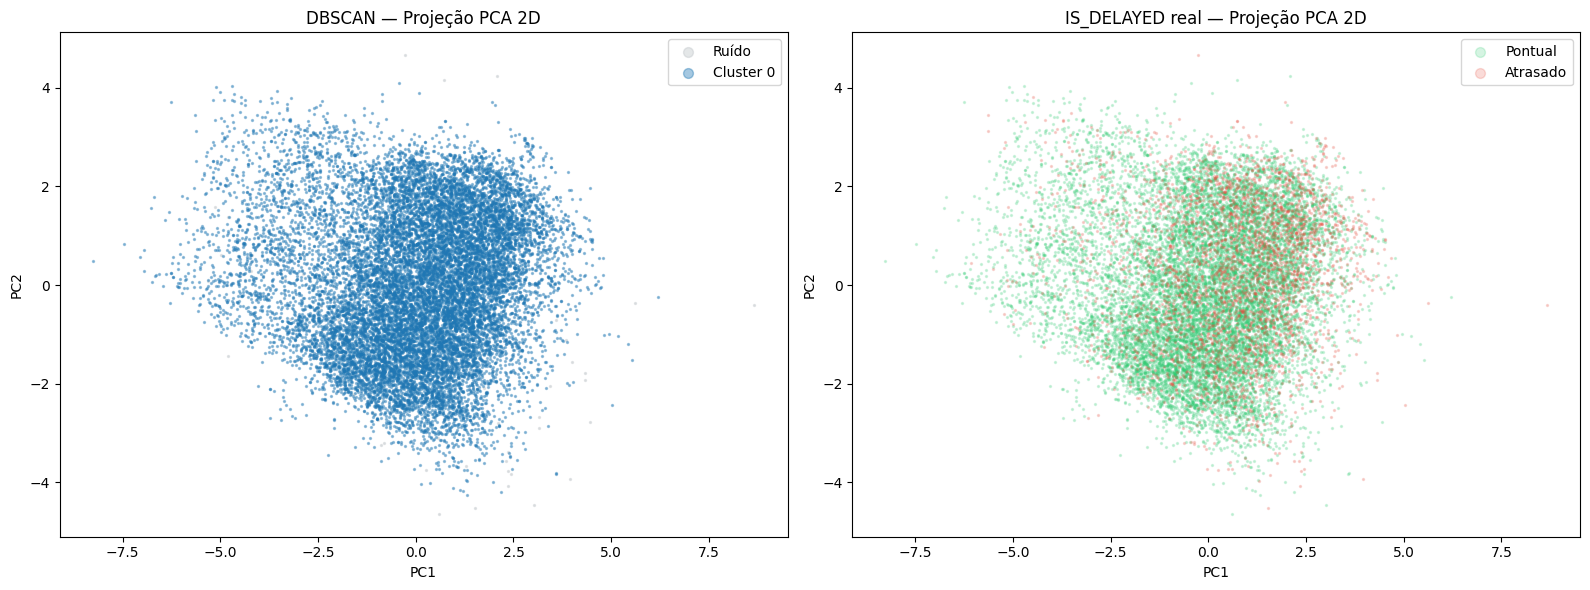

In [13]:
# Visualização 2D com PCA — DBSCAN
X_db_pca = PCA(n_components=2, random_state=42).fit_transform(X_db)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

unique_labels = sorted(set(db_labels))
palette = {-1: '#bdc3c7'}  # cinza para ruído
colors_map = sns.color_palette('tab10', n_colors=max(0, n_clusters))
for i, lbl in enumerate([l for l in unique_labels if l != -1]):
    palette[lbl] = colors_map[i]

for lbl in unique_labels:
    mask = db_labels == lbl
    name = 'Ruído' if lbl == -1 else f'Cluster {lbl}'
    axes[0].scatter(X_db_pca[mask, 0], X_db_pca[mask, 1],
                    s=2, alpha=0.4, label=name, color=palette[lbl])
axes[0].set_title('DBSCAN — Projeção PCA 2D', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=5)

for label, name, color in [(0, 'Pontual', '#2ecc71'), (1, 'Atrasado', '#e74c3c')]:
    mask = y_db == label
    axes[1].scatter(X_db_pca[mask, 0], X_db_pca[mask, 1],
                    s=2, alpha=0.2, label=name, color=color)
axes[1].set_title('IS_DELAYED real — Projeção PCA 2D', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

## 5. Comparação entre os Modelos

In [14]:
# Métricas de avaliação de clustering (sem usar IS_DELAYED)
print('=' * 55)
print('MÉTRICAS DE CLUSTERING (sem usar a variável alvo)')
print('=' * 55)

# K-Means — sobre amostra de 50k para agilizar
sample_idx = np.random.choice(len(X_scaled), 50000, replace=False)
km_sil = silhouette_score(X_scaled[sample_idx], km_labels[sample_idx], random_state=42)
km_db_score = davies_bouldin_score(X_scaled[sample_idx], km_labels[sample_idx])

print(f'\nK-Means (k={KMEANS_K}):')
print(f'  Silhouette Score:      {km_sil:.4f}  (>0 melhor, máx 1)')
print(f'  Davies-Bouldin Index:  {km_db_score:.4f}  (menor melhor)')

# DBSCAN — excluindo ruído
mask_no_noise = db_labels != -1
if mask_no_noise.sum() > 1000 and len(set(db_labels[mask_no_noise])) > 1:
    db_sil = silhouette_score(X_db[mask_no_noise], db_labels[mask_no_noise],
                              sample_size=10000, random_state=42)
    db_dbi = davies_bouldin_score(X_db[mask_no_noise], db_labels[mask_no_noise])
    print(f'\nDBSCAN (eps={eps_sugerido}, min_samples={MIN_SAMPLES}):')
    print(f'  Silhouette Score:      {db_sil:.4f}  (excluindo ruído)')
    print(f'  Davies-Bouldin Index:  {db_dbi:.4f}  (excluindo ruído)')
    print(f'  Ruído:                 {n_noise/len(db_labels)*100:.1f}% dos pontos')
else:
    print(f'\nDBSCAN: poucos pontos não-ruído para calcular métricas de separação.')
    print(f'  Ruído: {n_noise/len(db_labels)*100:.1f}% dos pontos — eps pode precisar de ajuste.')

print(f'\n{"-"*55}')
print('TAXA DE ATRASO POR CLUSTER (validação com IS_DELAYED):')
print(f'  Média geral do dataset: {y_true.mean()*100:.2f}%')
print(f'\n  K-Means:')
for c in range(KMEANS_K):
    rate = df_result[df_result['CLUSTER_KM']==c]['IS_DELAYED'].mean()*100
    print(f'    Cluster {c}: {rate:.2f}%')
print(f'\n  DBSCAN:')
for lbl in sorted(set(db_labels)):
    name = 'Ruído ' if lbl == -1 else f'Cluster {lbl}'
    rate = df_db[df_db['CLUSTER_DB']==lbl]['IS_DELAYED'].mean()*100
    print(f'    {name}: {rate:.2f}%')

MÉTRICAS DE CLUSTERING (sem usar a variável alvo)

K-Means (k=2):
  Silhouette Score:      0.1380  (>0 melhor, máx 1)
  Davies-Bouldin Index:  2.3129  (menor melhor)

DBSCAN: poucos pontos não-ruído para calcular métricas de separação.
  Ruído: 0.4% dos pontos — eps pode precisar de ajuste.

-------------------------------------------------------
TAXA DE ATRASO POR CLUSTER (validação com IS_DELAYED):
  Média geral do dataset: 18.60%

  K-Means:
    Cluster 0: 11.66%
    Cluster 1: 23.18%

  DBSCAN:
    Ruído : 35.62%
    Cluster 0: 18.88%


## 6. Conclusões

### K-Means
- Divide os voos em grupos com **perfis operacionais distintos** (hora do dia, distância, companhia, etc.)
- A variação na taxa de atraso entre clusters confirma que o modelo capturou **padrões reais** nos dados
- Limitação: assume clusters esféricos e exige definir k previamente

### DBSCAN
- Identifica **voos atípicos** (ruído) que não se encaixam em nenhum grupo denso
- Não requer definir o número de clusters, mas é sensível aos parâmetros `eps` e `min_samples`
- Para dados de voos — relativamente uniformes no espaço de features — tende a gerar um único cluster grande com bastante ruído

### Interpretação geral
O clustering não supervisionado **não prevê atraso diretamente**, mas revela que existem **perfis de voo estruturalmente diferentes** com probabilidades distintas de atraso. Esses perfis podem complementar o modelo supervisionado — por exemplo, o cluster com maior taxa histórica de atraso pode ser uma feature adicional.